In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler

In [17]:
class WindowDataset(Dataset):
    # 단변량 시계열 데이터에서 입력 값, 정받ㅂ 값을 만드는 Dataset
    def __init__(self, _data, _window):
        # _data : (N, ) 형태가 1차원 tensor 데이터
        # _window : 과거의 몇개의 데이터를 볼 것인가? (구간 설정)
        self.data = _data
        self.window = _window
        # 유효 샘플의 개수는 학습 데이터의 개수는 data의 전체 길이에서 -1
        # 입력 데이터는 전체 길이 - 윈도우
        self.n = len(_data) - _window
    
    # __len__(), __getitem__() 두개의 특수 합수들은 DataLoader에서 자동으로 호출해서 사용이 되는 부분
    def __len__(self):
        return max(self.n, 0)
    
    def __getitem__(self, idx):
        # 변환
        # x -> 입력 데이터 (윈도우의 구간을 나타내는 구간) --> 문제
        # y -> 입력 데이터 다음 행의 데이터 --> 정답
        x = self.data[idx : idx+self.window].unsqueeze(-1)  # (window,) -> (window, 1)
        y = self.data[idx + self.window].unsqueeze(-1)
        return x, y

In [18]:
# RNN class 정의
class RNNReg(nn.Module):
    # 해당 class에서 정의되는 함수는 생성자함수, foward()함수
    
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers = 1,
        nonlinearity = 'tanh',
        dropout = 0.0,
        bidirectional = False,
        batch_first = True
    ):
        # 부모 클래스의 생성자 함수 호출
        super().__init__()
        self.rnn = nn.RNN(
            input_size= input_size,
            hidden_size= hidden_size,
            num_layers= num_layers,
            nonlinearity=nonlinearity,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=batch_first
        )
        #self.head = nn.Linear(hidden_size, 1)      # 1차원 스칼라 회귀
        # bidirectional의 값이 False인 경우에는 hidden_size을 사용
        # 만약 True라면 hidden_size * 2
        out_features = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Linear(out_features, 1)
        
    def forward(self, x):
        # out -> 모든 시점에서는 은닉층의 값(결과)
        # h_n -> 마지막 시점에서의 은닉층의 값(결과) -> 층이 존재하면 층별 마지막 값
        # -> 시계열 분석은 마지막 시점을 사용
        out, h_n = self.rnn(x)
        # 가장 마지막 은닉의 값을 사용(마지막 층의 값)
        last_hidden = h_n[-1]
        res = self.head(last_hidden)
        return res

### 문제
- csv 폴더 안에 있는 AAPL.csv 파일을 로드
- 해당 데이터프레임에서 Date, Adj Close 컬럼을 제외한 나머지는 모두 삭제
- 결측치가 포함되어있는지 확인하고 결측치 데이터가 전체 데이터 수의 비해 매우 작은 크기라면 제거
- 해당 데이터셋의 순서가 시간의 순서와 같은지 확인 (시간 컬럼을 기준으로 오름차순 정렬)
- tensor 데이터를 생성하기 위해 Adj Close의 데이터 array 형태((N, 1))로 변경
- train, test의 비율이 75:25의 비율로 데이터를 나눠준다.
- train과 test를 스케일러를 이용하여 스케일링
- train과 test를 Tensor의 형태로 변환
- tensor형태로 변환된 데이터를 Windowdataset의 형태로 변경하고 DataLoader를 이용하여 학습에서 사용하기 편한 형태로 변경 (window의 개수는 60)

In [19]:
df = pd.read_csv("../csv/AAPL.csv")
df.head(0)

,Date,Open,High,Low,Close,Adj Close,Volume


In [20]:
df = df[['Date','Adj Close']]

In [21]:
df.isna().sum()

Date         0
Adj Close    1
dtype: int64

In [22]:
df = df.dropna()

In [23]:
df.sort_values('Date', inplace=True)

In [24]:
# df[['Adj Close']].values
data = df['Adj Close'].values.reshape(-1, 1)

In [25]:
split_idx = int(len(data) * 0.75)
train_data = data[: split_idx]
test_data = data[split_idx :] 

In [26]:
scaler = StandardScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

In [27]:
train_data = torch.tensor(train_data.squeeze(-1), dtype=torch.float32)
test_data = torch.tensor(test_data.squeeze(-1), dtype=torch.float32)

In [28]:
window = 60
train_ds = WindowDataset(train_data, window)
test_ds = WindowDataset(test_data, window)
train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=64)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=128)   

In [ ]:
rnn_model = RNNReg(
    input_size=1, hidden_size=64
)

# 회귀 분석 -> 손실 함수 -> MSE
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
# loss의 미분 폭주 방지용 설정
max_grad_norm = 1.0

# 검증 단계 함수 생성
# 함수 호출 시 동시에 실행이 되는 데코레이터 생성
@torch.no_grad()
def evaliate_mse(dataloader):
    rnn_model.eval()
    total_loss = 0.0
    total_n = 0
    # with torch.no_grad():
    for x, y in dataloader:
        x = x.float()
        y = y.float()
        yhat = rnn_model(x)
        loss = criterion(yhat, y)
        # 총 손실
        total_loss += loss.item() * y.size(0)
        # loss.itme() : 손실의 평균
        # size(0) : 개수
        total_n += y.size(0)
    return total_loss / max(total_n, 1)

In [ ]:
# 반복 학습 루프

# 학습 데이터의 loss들 검증 데이터의 loss들을 저장 -> 시각화
train_history = []
val_history = []


epoch : 1, train_mse : 0.105, test_mse : 304.94949
epoch : 2, train_mse : 0.003, test_mse : 292.91805
epoch : 3, train_mse : 0.002, test_mse : 284.40262
epoch : 4, train_mse : 0.002, test_mse : 278.61366
epoch : 5, train_mse : 0.002, test_mse : 272.97952
epoch : 6, train_mse : 0.002, test_mse : 268.31483
epoch : 7, train_mse : 0.002, test_mse : 263.21646
epoch : 8, train_mse : 0.002, test_mse : 260.40788
epoch : 9, train_mse : 0.002, test_mse : 256.77237
epoch : 10, train_mse : 0.002, test_mse : 253.55722
epoch : 11, train_mse : 0.002, test_mse : 250.07214
epoch : 12, train_mse : 0.002, test_mse : 248.05647
epoch : 13, train_mse : 0.002, test_mse : 245.18128
epoch : 14, train_mse : 0.002, test_mse : 242.33115
epoch : 15, train_mse : 0.001, test_mse : 240.41559
epoch : 16, train_mse : 0.001, test_mse : 237.96332
epoch : 17, train_mse : 0.001, test_mse : 235.73907
epoch : 18, train_mse : 0.001, test_mse : 233.56157
epoch : 19, train_mse : 0.001, test_mse : 231.25287
epoch : 20, train_mse

In [ ]:

for epoch in range(20):
    rnn_model.train()
    running=0.0
    n_seen = 0
    
    for x, y in train_dl:
        x = x.float()
        y = y.float()
        
        optimizer.zero_grad()
        yhat = rnn_model(x)
        loss = criterion(yhat, y)
        loss.backward()
        # 미분값 폭주 방지
        nn.utils.clip_grad_norm_(rnn_model.parameters(), max_grad_norm)
        
        optimizer.step()
        
        running += loss.item() * y.size(0)
        n_seen += y.size(0)
        
    train_mse = running / max(n_seen, 1)
    test_mse = evaliate_mse(test_dl)
    train_history.append(train_mse)
    val_history.append(test_mse)
    print(f"epoch : {epoch + 1}, train_mse : {round(train_mse, 3)}, test_mse : {round(test_mse, 5)}")

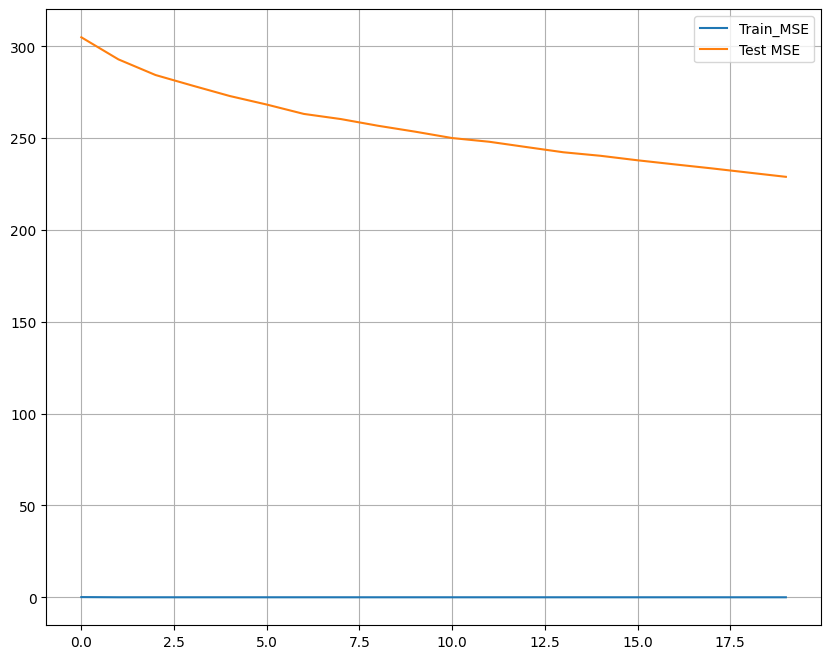

In [32]:
plt.figure(figsize=(10, 8))
plt.plot(train_history, label='Train_MSE')
plt.plot(val_history, label='Test MSE')
plt.legend()
plt.grid(True)
plt.show()